In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. TẢI DỮ LIỆU
file_path = "merged/data.csv"
df = pd.read_csv(file_path)


In [2]:
# Explore kiểu dữ liệu của tất cả các cột
try:
    
    print(" TỔNG QUAN DỮ LIỆU:")
    
    # Xem chi tiết 
    df.info()
    
    # In ra 5 dòng ngẫu nhiên để xem chuỗi "10%" hay "10" 
    print(df.sample(5))

except FileNotFoundError:
    print("Không tìm thấy file csv.")

 TỔNG QUAN DỮ LIỆU:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19817 entries, 0 to 19816
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    19817 non-null  int64  
 1   product_name                  19817 non-null  object 
 2   product_url                   19817 non-null  object 
 3   category_id                   19817 non-null  int64  
 4   category_name                 19817 non-null  object 
 5   category_root_name            19817 non-null  object 
 6   price                         19811 non-null  float64
 7   original_price                19811 non-null  float64
 8   discount_rate                 19811 non-null  float64
 9   quantity_sold                 14172 non-null  float64
 10  rating_average                19811 non-null  float64
 11  review_count                  19811 non-null  float64
 12  is_return_policy              19811 non-

Ta thấy được `return_rate` và `cancel_by_seller_rate` chưa đúng với định dạng float của tỉ lệ. Có dòng dữ liệu đang chứa thêm kí tự "%" còn có dòng thì không.

In [3]:
# SỬA ĐỔI KIỂU DỮ LIỆU (DATA TYPE CONVERSION)

# Hàm xử lý các cột % (có ký tự %) thành số thực (float)
def clean_percentage(x):
    """Hàm làm sạch chuỗi phần trăm: '12%' -> 12.0, '<1%' -> 0.5"""
    if pd.isna(x): 
        return 0.0
    x = str(x).strip()
    
    # Xử lý trường hợp đặc biệt "<1%"
    if '<' in x:
        return 0.5 # Gán giá trị nhỏ tượng trưng
    
    # Loại bỏ ký tự % và chuyển sang float
    clean_val = x.replace('%', '').replace(' ', '')
    try:
        return float(clean_val)
    except:
        return 0.0

# Áp dụng cho 2 cột tỷ lệ
df['cancel_by_seller_rate'] = df['cancel_by_seller_rate'].apply(clean_percentage)
df['return_rate'] = df['return_rate'].apply(clean_percentage)

# Chuyển đổi các cột số khác để chắc chắn 
cols_to_numeric = ['price', 'original_price', 'quantity_sold', 'total_follower', 'review_count']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(df[['cancel_by_seller_rate', 'return_rate']].dtypes)

cancel_by_seller_rate    float64
return_rate              float64
dtype: object


In [4]:
# Xử lý data conflict ở discount_rate
df['discount_rate'] = df['original_price']/df['price']-1
df.to_csv("clean_data.csv", index=True)


# Feature engineering

- `reputation_score`: điểm uy tín thực sự giữa `rating_average` và `review_count` (Rating 5 sao mà chỉ có 1 review thì không bằng 4.5 sao mà có 1000 review.)
- `trust_level`: điểm tín nhiệm là tổng giữa các flag uy tín `is_official`, `is_authentic` và `is_brand`
- `review_to_sold_ratio`: tỉ lệ tương tác so với lượt mua (`review_count`/(`quantity_sold`+1))
- `shop_potential`: đo độ nổi tiếng của shop dựa trên tổng của `store_review_count` và `total_follower`

***Phục vụ cho câu hỏi 2***
- `total_visuals`: tổng số lượng video và hình ảnh
- `has_video`: flag kiểm tra sản phẩm có video không

***Phục vụ cho câu hỏi 3***
- `discount_amount`: số tiền giảm thực tế (hiệu của `original_price` và `price`)
- `price_vs_category`: giá tương đối của sản phẩm so với danh mục, so sánh giá sản phẩm so với giá trung bình của tất cả các sản phẩm cùng danh mục. <1: rẻ hơn trung bình; >1: mắc hơn trung bình.

***Phục vụ cho câu hỏi 5***
- `hot_keyword_count`: đếm số lần xuất hiện những từ khóa "giật tít" có trong tiêu đề.

***Phục vụ cho câu hỏi 7***
- `name_length`: độ dài của tiêu đề
- `name_word_count`: số chữ của tiêu đề

In [5]:
import re

# Giả sử df là DataFrame của bạn
print("🚀 ĐANG TẠO CÁC FEATURE THEO YÊU CẦU...")

# ==============================================================================
# 1. NHÓM UY TÍN & NIỀM TIN (TRUST & REPUTATION)
# ==============================================================================

# 1.1. Reputation Score (Điểm uy tín thực sự)
# Công thức: Rating * log(Review + 1).
# Dùng log để giảm bớt sự chênh lệch quá lớn của Review Count (giữa 10 và 10000).
df['reputation_score'] = df['rating_average'] * np.log1p(df['review_count'])

# 1.2. Trust Level (Điểm tín nhiệm)
# Tổng hợp các cờ uy tín (Official, Authentic, Brand)
# Chuyển đổi True/False/NaN thành 0/1 rồi cộng lại
df['trust_level'] = (df['is_official'].fillna(0).astype(int) + 
                     df['is_authentic'].fillna(0).astype(int) + 
                     df['is_brand'].fillna(0).astype(int))

# 1.3. Review to Sold Ratio (Tỷ lệ tương tác)
# Công thức: Review / (Sold + 1)
# Cho biết mức độ sẵn sàng feedback của người mua
df['review_to_sold_ratio'] = df['review_count'] / (df['quantity_sold'].fillna(0) + 1)

# 1.4. Shop Potential (Độ nổi tiếng của Shop)
# Công thức: Store Review + Total Follower
df['shop_potential'] = df['store_review_count'].fillna(0) + df['total_follower'].fillna(0)


# ==============================================================================
# 2. NHÓM HÌNH ẢNH & VIDEO (VISUALS) - Cho Câu 2
# ==============================================================================

# 2.1. Total Visuals (Tổng tư liệu hình ảnh)
df['total_visuals'] = df['image_count'].fillna(0) + df['video_count'].fillna(0)

# 2.2. Has Video (Có video không?)
# 1 nếu có, 0 nếu không
df['has_video'] = df['video_count'].apply(lambda x: 1 if x > 0 else 0)


# ==============================================================================
# 3. NHÓM GIÁ (PRICING) - Cho Câu 3
# ==============================================================================

# 3.1. Discount Amount (Số tiền giảm thực tế)
df['discount_amount'] = df['original_price'] - df['price']
# Xử lý số âm (nếu có lỗi dữ liệu)
df['discount_amount'] = df['discount_amount'].apply(lambda x: x if x > 0 else 0)

# 3.2. Price vs Category (Giá tương đối)
# So sánh giá sp với giá trung bình của danh mục đó
if 'category_root_name' in df.columns:
    # Tính giá trung bình của từng danh mục
    df['category_avg_price'] = df.groupby('category_root_name')['price'].transform('mean')
    # Tính tỷ lệ: Giá SP / (Giá TB + 1)
    df['price_vs_category'] = df['price'] / (df['category_avg_price'] + 1)
else:
    df['price_vs_category'] = 1.0 # Mặc định nếu thiếu cột category


# ==============================================================================
# 4. NHÓM TỪ KHÓA & TIÊU ĐỀ (TEXT & SEO) - Cho Câu 5 & 7
# ==============================================================================

# 4.1. Hot Keyword Count (Đếm từ khóa "giật tít")
# Danh sách các từ khóa hấp dẫn
keywords = ['chính hãng', 'cao cấp', 'freeship', 'xịn', 'hot', 'giảm', 'sale', 'tặng', 'combo', 'bảo hành', 'nhập khẩu', 'siêu rẻ']
pattern = '|'.join(keywords)

# Đếm số lần xuất hiện (count) thay vì chỉ kiểm tra có hay không (contains)
df['hot_keyword_count'] = df['product_name'].astype(str).str.lower().str.count(pattern).fillna(0).astype(int)

# 4.2. Name Length (Độ dài tiêu đề - Ký tự)
df['name_length'] = df['product_name'].astype(str).apply(len)

# 4.3. Name Word Count (Độ dài tiêu đề - Số từ)
df['name_word_count'] = df['product_name'].astype(str).apply(lambda x: len(x.split()))


# ==============================================================================
# KIỂM TRA KẾT QUẢ
# ==============================================================================
print("✅ Đã tạo xong 11 feature mới theo yêu cầu.")

# Hiển thị 5 dòng đầu của các cột mới để kiểm tra
new_cols = ['reputation_score', 'trust_level', 'shop_potential', 
            'has_video', 'discount_amount', 'price_vs_category',
            'hot_keyword_count', 'name_word_count']
            
print(df[new_cols].head())



🚀 ĐANG TẠO CÁC FEATURE THEO YÊU CẦU...
✅ Đã tạo xong 11 feature mới theo yêu cầu.
   reputation_score  trust_level  shop_potential  has_video  discount_amount  \
0          4.943755            2         10284.0          0         100000.0   
1         13.862944            2          3184.0          1         100000.0   
2         11.512925            2          3184.0          1         100000.0   
3          6.931472            2         10284.0          0         100000.0   
4          9.729551            2          3184.0          1         100000.0   

   price_vs_category  hot_keyword_count  name_word_count  
0           1.219578                  1                7  
1           1.366599                  0               10  
2           1.294096                  0               10  
3           1.305126                  0                7  
4           1.228840                  0               10  


In [ ]:
# Lưu lại file (nếu cần)
df.to_csv("tiki_data_engineered.csv", index=False, encoding='utf-8-sig')

📊 BẮT ĐẦU PHÂN TÍCH TÁC ĐỘNG CỦA GIÁ...


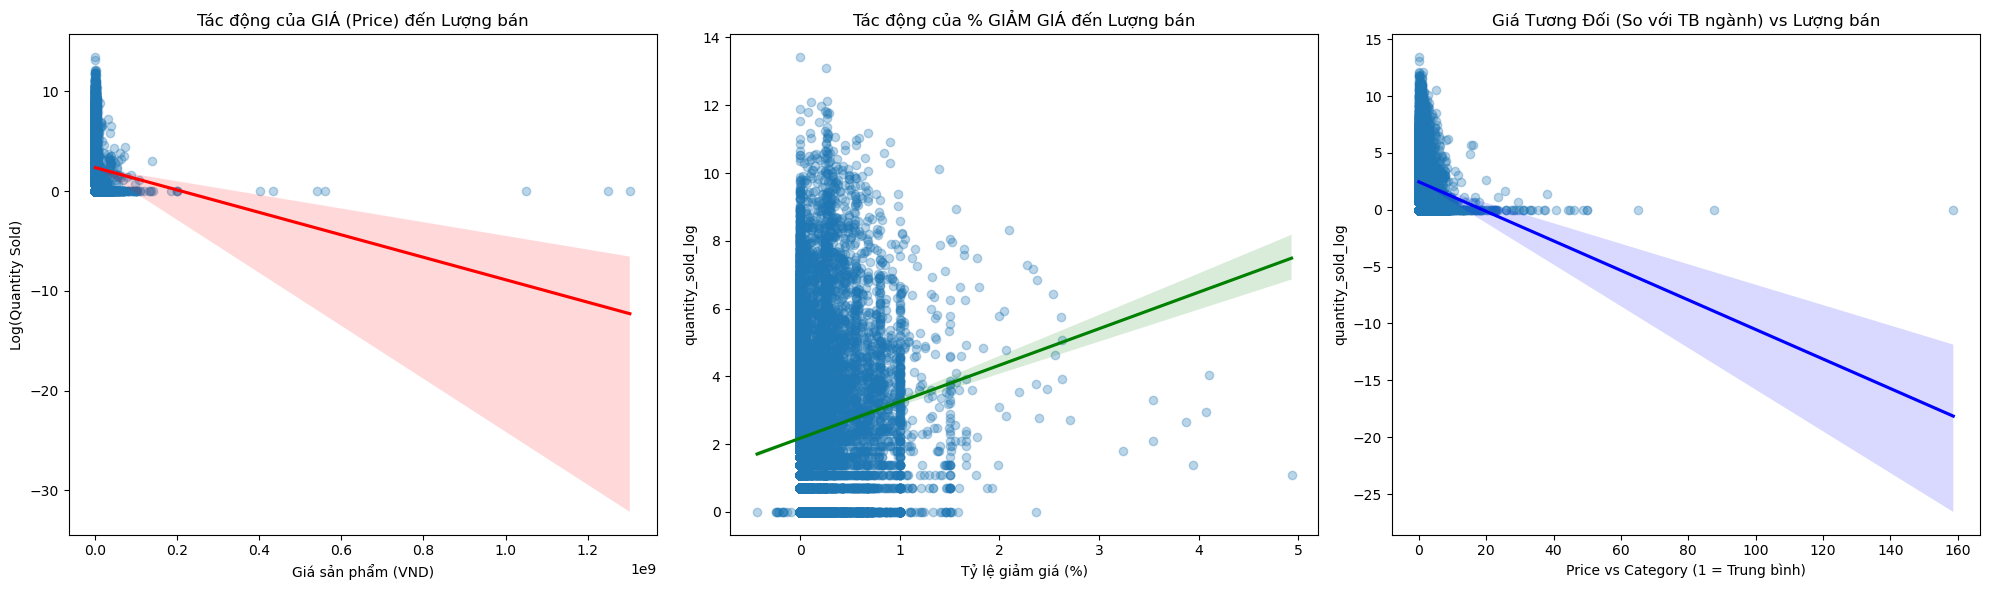


🔢 Hệ số tương quan với Quantity Sold:
quantity_sold        1.000000
discount_rate        0.025740
discount_amount     -0.004258
price               -0.007475
price_vs_category   -0.013037
Name: quantity_sold, dtype: float64


C:\Users\chiph\AppData\Local\Temp\ipykernel_27212\1604802937.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('price_bin')['quantity_sold'].mean().reset_index()
C:\Users\chiph\AppData\Local\Temp\ipykernel_27212\1604802937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_bin', y='quantity_sold', data=bin_stats, palette='Blues_d')


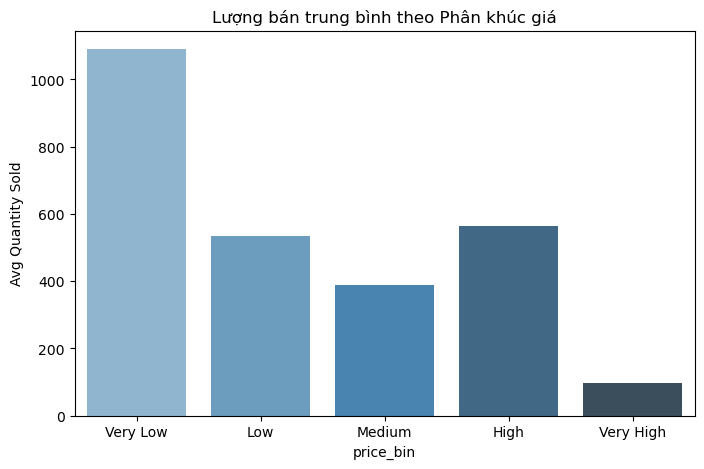


📈 Kết quả Mô hình Hồi quy (Tác động của các yếu tố giá):
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.3031      0.020    117.236      0.000       2.265       2.342
price             -4.568e-09   9.72e-10     -4.699      0.000   -6.47e-09   -2.66e-09
discount_rate         1.1552      0.062     18.564      0.000       1.033       1.277
discount_amount   -1.418e-07   1.38e-08    -10.242      0.000   -1.69e-07   -1.15e-07
price_vs_category    -0.1074      0.007    -15.011      0.000      -0.121      -0.093


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df là dataframe của bạn (đã có quantity_sold, price, discount_rate, price_vs_category...)
# Nếu chưa có log sold, tạo lại để vẽ cho đẹp
df['quantity_sold_log'] = np.log1p(df['quantity_sold'])

print("📊 BẮT ĐẦU PHÂN TÍCH TÁC ĐỘNG CỦA GIÁ...")

# ==============================================================================
# 1. TRỰC QUAN HÓA (SCATTER PLOTS)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Biểu đồ 1: Giá vs Lượng bán (Log)
sns.regplot(x='price', y='quantity_sold_log', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Tác động của GIÁ (Price) đến Lượng bán')
axes[0].set_xlabel('Giá sản phẩm (VND)')
axes[0].set_ylabel('Log(Quantity Sold)')

# Biểu đồ 2: % Giảm giá vs Lượng bán (Log)
sns.regplot(x='discount_rate', y='quantity_sold_log', data=df, ax=axes[1], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
axes[1].set_title('Tác động của % GIẢM GIÁ đến Lượng bán')
axes[1].set_xlabel('Tỷ lệ giảm giá (%)')

# Biểu đồ 3: Giá tương đối vs Lượng bán (Log)
# (Đây là feature quan trọng nhất: Đắt hay Rẻ so với danh mục)
sns.regplot(x='price_vs_category', y='quantity_sold_log', data=df, ax=axes[2], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
axes[2].set_title('Giá Tương Đối (So với TB ngành) vs Lượng bán')
axes[2].set_xlabel('Price vs Category (1 = Trung bình)')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. TÍNH HỆ SỐ TƯƠNG QUAN (CORRELATION)
# ==============================================================================
price_cols = ['quantity_sold', 'price', 'discount_rate', 'discount_amount', 'price_vs_category']
# Lọc các cột tồn tại
price_cols = [c for c in price_cols if c in df.columns]

corr_price = df[price_cols].corr()['quantity_sold'].sort_values(ascending=False)
print("\n🔢 Hệ số tương quan với Quantity Sold:")
print(corr_price)

# ==============================================================================
# 3. PHÂN TÍCH SÂU: PHÂN KHÚC GIÁ (PRICE BINS)
# ==============================================================================
# Chia giá thành 5 nhóm (Rất rẻ, Rẻ, Trung bình, Cao, Rất cao)
try:
    df['price_bin'] = pd.qcut(df['price'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    # Tính trung bình lượng bán cho mỗi nhóm
    bin_stats = df.groupby('price_bin')['quantity_sold'].mean().reset_index()
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x='price_bin', y='quantity_sold', data=bin_stats, palette='Blues_d')
    plt.title('Lượng bán trung bình theo Phân khúc giá')
    plt.ylabel('Avg Quantity Sold')
    plt.show()
except:
    print("Không đủ dữ liệu để chia bin.")

# ==============================================================================
# 4. MÔ HÌNH HỒI QUY ĐƠN GIẢN (OLS REGRESSION)
# Để xem tác động của từng yếu tố khi giữ nguyên các yếu tố khác
# ==============================================================================
import statsmodels.api as sm

# Chọn các biến độc lập liên quan đến giá
X_cols = ['price', 'discount_rate', 'discount_amount', 'price_vs_category', 'is_charm_price']
X_cols = [c for c in X_cols if c in df.columns]

# Chuẩn bị dữ liệu (bỏ Na)
df_reg = df.dropna(subset=X_cols + ['quantity_sold_log'])

X = df_reg[X_cols]
X = sm.add_constant(X) # Thêm hằng số chặn
y = df_reg['quantity_sold_log'] # Dùng log để mô hình tốt hơn

model = sm.OLS(y, X).fit()
print("\n📈 Kết quả Mô hình Hồi quy (Tác động của các yếu tố giá):")
print(model.summary().tables[1])

# Scaling Data

- Giữ nguyên các cột đang ở dạng binary
- Scale các cột là biến số liên tục


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Giả sử df là DataFrame đang chứa đầy đủ các feature
print("⚖️ ĐANG CHUẨN HÓA (SCALING) - GHI ĐÈ TRỰC TIẾP...")

# 1. XÁC ĐỊNH CÁC CỘT CẦN SCALE (Biến số liên tục)
# Lưu ý: KHÔNG được scale các cột Binary (0/1) như is_official, is_successful
cols_to_scale = [
    # --- Tiền tệ ---
    'price', 'original_price', 'discount_amount', 
    
    # --- Số lượng ---
    'quantity_sold', 'review_count', 'total_follower', 'store_review_count',
    'image_count', 'video_count', 'total_visuals', 'name_length', 'name_word_count',
    
    # --- Điểm số & Tỷ lệ ---
    'reputation_score', 'price_vs_category', 
    'review_to_sold_ratio' , 'trust_level',
    'rating_average', 'discount_rate', 
    'cancel_by_seller_rate', 'return_rate'
]

# Lọc các cột thực sự tồn tại
valid_cols = [c for c in cols_to_scale if c in df.columns]

# 2. XỬ LÝ LỖI TRƯỚC KHI SCALE
# Thay thế vô cực (inf) và NaN bằng 0 để tránh lỗi Scaler
df[valid_cols] = df[valid_cols].replace([np.inf, -np.inf], 0).fillna(0)

# 3. THỰC HIỆN SCALE VÀ GHI ĐÈ (QUAN TRỌNG)
scaler = MinMaxScaler()

# Lệnh này sẽ tính toán và đè giá trị mới (0-1) lên chính cột cũ
df[valid_cols] = scaler.fit_transform(df[valid_cols])

print(f"✅ Đã chuẩn hóa xong {len(valid_cols)} cột.")
print("   (Tất cả giá trị bây giờ đều nằm trong khoảng 0 đến 1)")

# Kiểm tra thử
print("\n📊 Dữ liệu sau khi Scale:")
print(df[['price', 'total_follower', 'reputation_score']].head())

In [ ]:
# Lưu lại file (nếu cần)
df.to_csv("tiki_data_scaling.csv", index=False, encoding='utf-8-sig')

# Feature selection

- Giữ lại các cột đã scale và các cột Binary (0/1). Bỏ cột rác/text.
- 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình kích thước biểu đồ
plt.style.use('ggplot')
pd.set_option('display.max_rows', 500)

print("📊 ĐANG PHÂN TÍCH DỮ LIỆU ĐỂ CHỌN LỌC FEATURE...")

# ==============================================================================
# 1. KIỂM TRA ĐA CỘNG TUYẾN (CORRELATION HEATMAP)
# Mục tiêu: Tìm các cặp feature tương quan quá mạnh (> 0.9) để loại bớt
# ==============================================================================

# Tính ma trận tương quan
# Chỉ lấy các cột số (đã scale) để tính
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))
# Tạo mặt nạ che nửa trên tam giác để dễ nhìn
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Ma trận tương quan giữa các biến (Correlation Heatmap)', fontsize=16)
plt.show()

# --- GỢI Ý TỰ ĐỘNG ---
print("\n🔍 [GỢI Ý 1] CÁC CẶP FEATURE TRÙNG LẶP THÔNG TIN (Corr > 0.9):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            print(f"   ⚠️  {colname_i} <--> {colname_j} : {corr_matrix.iloc[i, j]:.2f}")
            # Gợi ý bỏ cột sau (thường là cột ít quan trọng hơn trong 2 cột)
            high_corr_pairs.append(colname_j)

# ==============================================================================
# 2. KIỂM TRA TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (TARGET CORRELATION)
# Mục tiêu: Tìm các feature "vô dụng" (ít ảnh hưởng đến quantity_sold)
# ==============================================================================

target = 'quantity_sold' # Biến mục tiêu của bạn (đã scale)

if target in numeric_df.columns:
    # Tính tương quan tuyệt đối với target
    target_corr = numeric_df.corrwith(numeric_df[target]).abs().sort_values(ascending=False)
    
    # Bỏ chính nó ra khỏi biểu đồ
    target_corr = target_corr.drop(target, errors='ignore')
    
    plt.figure(figsize=(10, 12))
    sns.barplot(x=target_corr.values, y=target_corr.index, palette="magma")
    plt.title(f'Mức độ ảnh hưởng của các Feature đến {target}', fontsize=16)
    plt.xlabel('Hệ số tương quan (Absolute Correlation)')
    plt.show()
    
    # --- GỢI Ý TỰ ĐỘNG ---
    print(f"\n🔍 [GỢI Ý 2] CÁC FEATURE ÍT TÁC DỤNG VỚI '{target}' (Corr < 0.01):")
    low_corr_cols = target_corr[target_corr < 0.01].index.tolist()
    for col in low_corr_cols:
        print(f"   ❌ {col} (Corr: {target_corr[col]:.4f}) -> Xem xét loại bỏ")
else:
    print(f"\n⚠️ Không tìm thấy cột mục tiêu '{target}' để vẽ biểu đồ tương quan.")

# ==============================================================================
# 3. KIỂM TRA PHƯƠNG SAI (VARIANCE)
# Mục tiêu: Tìm các cột "chết" (giá trị không đổi ở mọi dòng)
# ==============================================================================
print("\n🔍 [GỢI Ý 3] CÁC CỘT DỮ LIỆU 'CHẾT' (Variance ~ 0):")
low_variance_cols = []
for col in numeric_df.columns:
    # Nếu độ lệch chuẩn = 0 nghĩa là tất cả giá trị đều giống hệt nhau
    if numeric_df[col].std() == 0:
        print(f"   ☠️  {col} (Giá trị không đổi) -> BẮT BUỘC LOẠI BỎ")
        low_variance_cols.append(col)

if not low_variance_cols:
    print("   (Không có cột nào bị lỗi variance = 0)")

review_count và store_review_count có mức độ ảnh hưởng (correlation) cao nhất đến quantity_sold. Đây là những tính năng quan trọng cần giữ lại.

original_price, price, is_brand, discount_amount, is_charm_price, total_visuals, review_to_sold_ratio có hệ số tương quan rất thấp (< 0.01). Đây là những ứng viên tiềm năng để loại bỏ.

cancel_by_seller_rate, return_rate, shop_risk_score không hiển thị thanh correlation nào, có nghĩa là chúng có giá trị không đổi (variance = 0) hoặc toàn là 0. Những cột này chắc chắn phải loại bỏ.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Giả sử df là DataFrame hiện tại của bạn (đã scale và đầy đủ feature)
# df = pd.read_csv("tiki_data_scaled_ready.csv")

print("🏁 LỰA CHỌN FEATURES DỰA TRÊN TRỰC QUAN HÓA")

# ==============================================================================
# 1. DANH SÁCH CÁC CỘT CẦN LOẠI BỎ (DROP)
# ==============================================================================
cols_to_drop = [
    # --- Nhóm 1: Định danh & Text (Không có giá trị dự đoán) ---
    'product_id', 'product_name', 'product_url', 
    'category_id', 'category_name', 
    'store_id', 'store_name', 'seller_id', 
    'brand_name', 'origin', 
    
    # --- Nhóm 2: Dữ liệu thô dạng chuỗi/status ---
    'cancel_by_seller_rate_status', 'return_rate_status',

    # --- Nhóm 3: Các cột "Chết" (Variance = 0) hoặc Corr quá thấp (< 0.01) ---
    # Dựa trên biểu đồ bạn cung cấp:
    'shop_risk_score',       # Corr = 0
    'cancel_by_seller_rate',        # Corr = 0 (tương đương cancel_rate)
    'return_rate',        # Corr = 0 (tương đương return_rate)
    'review_to_sold_ratio',  # Corr rất thấp
    'total_visuals',         # Corr rất thấp
    'is_charm_price',        # Corr rất thấp
    'discount_amount',       # Corr rất thấp
    'is_brand',              # Corr rất thấp
    
    # --- Nhóm 4: Loại bỏ đa cộng tuyến (Giữ lại 1 đại diện tốt nhất) ---
    # price và original_price tương quan cực cao -> Bỏ cả 2 gốc, giữ price_scaled hoặc price_vs_category
    'price', 
    # Bỏ các cột gốc đã được scale
    'quantity_sold', 'total_follower', 'review_count', 'store_review_count', 
    'image_count', 'video_count', 'rating_average', 'reputation_score'
]

# Tạo DataFrame sạch cho Model
# errors='ignore' để không lỗi nếu lỡ cột không có
df_model = df.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
# ==============================================================================
# 2. ONE-HOT ENCODING (Xử lý biến phân loại)
# ==============================================================================
# Chỉ còn category_root_name là cần one-hot
if 'category_root_name' in df_model.columns:
    # Thêm tham số dtype=int để ép về số 1 và 0
    df_model = pd.get_dummies(
        df_model, 
        columns=['category_root_name'], 
        drop_first=True, 
        dtype=int  
    )
# ==============================================================================
# 3. TÁCH X VÀ y
# ==============================================================================
target_col = 'is_successful' 

# X là tất cả trừ target và các biến leakage (tiết lộ kết quả)
# quantity_sold_scaled cần bỏ vì nó chính là đáp án đã được scale
X = df_model.drop(columns=['is_successful', 'quantity_sold_scaled'], errors='ignore')
y = df[target_col]

# Xử lý NaN lần cuối
X = X.fillna(0)

# ==============================================================================
# 4. CHIA TRAIN/TEST & LƯU FILE
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 50)
print(f"📊 DỮ LIỆU SẴN SÀNG CHO MODELING:")
print(f"Số lượng features: {X_train.shape[1]}")
print("\n📋 Danh sách Features giữ lại:")
print(list(X_train.columns))

X_train.to_csv("processed/X_train_final.csv", index=False)
y_train.to_csv("processed/y_train_final.csv", index=False)
X_test.to_csv("processed/X_test_final.csv", index=False)
y_test.to_csv("processed/y_test_final.csv", index=False)